# <font color='blue'> California Housing Prices </font>

The dataset for this study was downloaded from **Kaggle** ([link](https://www.kaggle.com/datasets/camnugent/california-housing-prices/data))

## <font color='purple'> Description of Dataset </font>

This is the dataset used in the second chapter of Aurélien Géron's recent book 'Hands-On Machine learning with Scikit-Learn and TensorFlow'. It serves as an excellent introduction to implementing machine learning algorithms because it requires rudimentary data cleaning, has an easily understandable list of variables and sits at an optimal size between being to toyish and too cumbersome.

The data contains information from the 1990 California census. So although it may not help you with predicting current housing prices like the Zillow Zestimate dataset, it does provide an accessible introductory dataset for teaching people about the basics of machine learning.

### <font color='blue'> Data Columns </font>

1. **longitude:** A measure of how far west a house is; a higher value is farther west
2. **latitude:** A measure of how far north a house is; a higher value is farther north
3. **housingMedianAge:** Median age of a house within a block; a lower number is a newer building
4. **totalRooms:** Total number of rooms within a block
5. **totalBedrooms:** Total number of bedrooms within a block
6. **population:** Total number of people residing within a block
7. **households:** Total number of households, a group of people residing within a home unit, for a block
8. **medianIncome:** Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. **medianHouseValue:** Median house value for households within a block (measured in US Dollars)
10. **oceanProximity:** Location of the house w.r.t ocean/sea

## <font color='orange'> Loading Dataset and Preprocessing </font>

In [2]:
# load the data
import pandas as pd

df = pd.read_csv("../data/raw/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
# finding null entries

null_columns = df.isnull().sum()
print(null_columns)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [16]:
# filter the data

bool_series = pd.isnull(df['total_bedrooms'])
filtered_bool = ~bool_series
filtered_df = df[filtered_bool]

# save the filtered data
filtered_df.to_csv("../data/processed/housing_filtered.csv", index=False)

In [18]:
# verify that there are no null entries in columns

null_entries = filtered_df.isnull().sum()
print(null_entries)

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## <font color='orange'> Distribution of Variables </font>

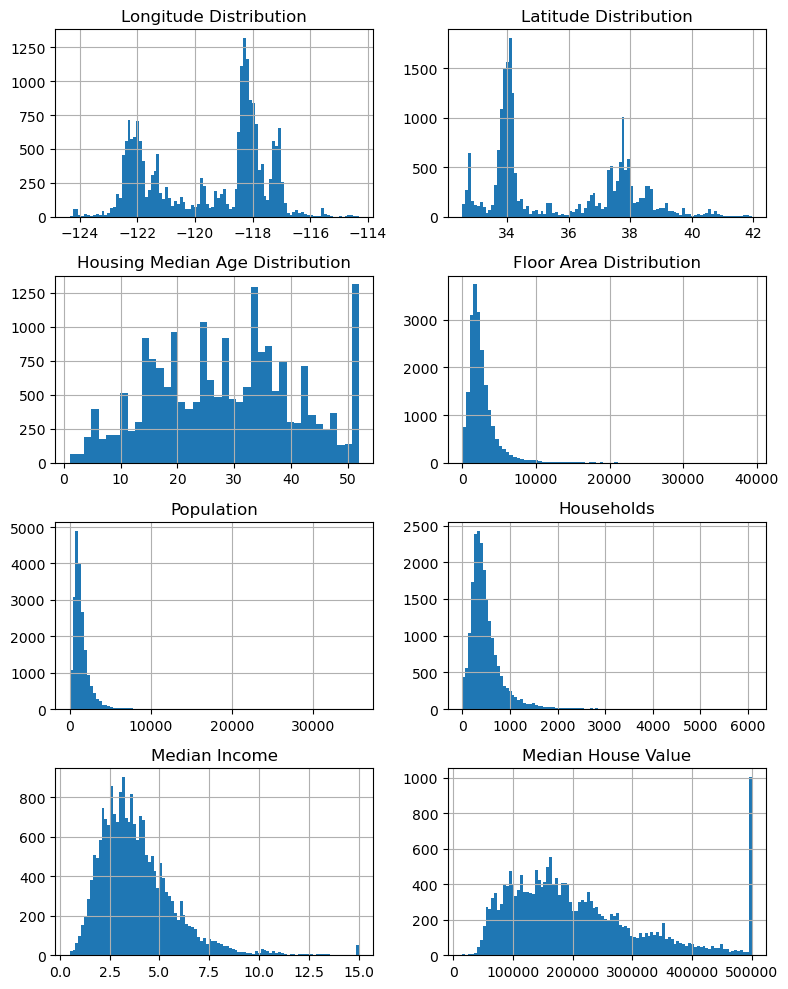

In [87]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8, 10))

filtered_df['longitude'].hist(bins=100, ax=axes[0,0])
axes[0,0].set_title('Longitude Distribution')


filtered_df['latitude'].hist(bins=100, ax=axes[0,1])
axes[0,1].set_title('Latitude Distribution')


filtered_df['housing_median_age'].hist(bins=40, ax=axes[1,0])
axes[1,0].set_title('Housing Median Age Distribution')


filtered_df['total_rooms'].hist(bins=80, ax=axes[1,1])
axes[1,1].set_title('Floor Area Distribution')


filtered_df['population'].hist(bins=100, ax=axes[2,0])
axes[2,0].set_title('Population')


filtered_df['households'].hist(bins=100, ax=axes[2,1])
axes[2,1].set_title('Households')


filtered_df['median_income'].hist(bins=100, ax=axes[3,0])
axes[3,0].set_title('Median Income')


filtered_df['median_house_value'].hist(bins=100, ax=axes[3,1])
axes[3,1].set_title('Median House Value')

 	 	
plt.tight_layout()
plt.savefig("../figures/housing_distributions.pdf")
plt.show()

## <font color='orange'> Median House Value vs Other Variables </font>

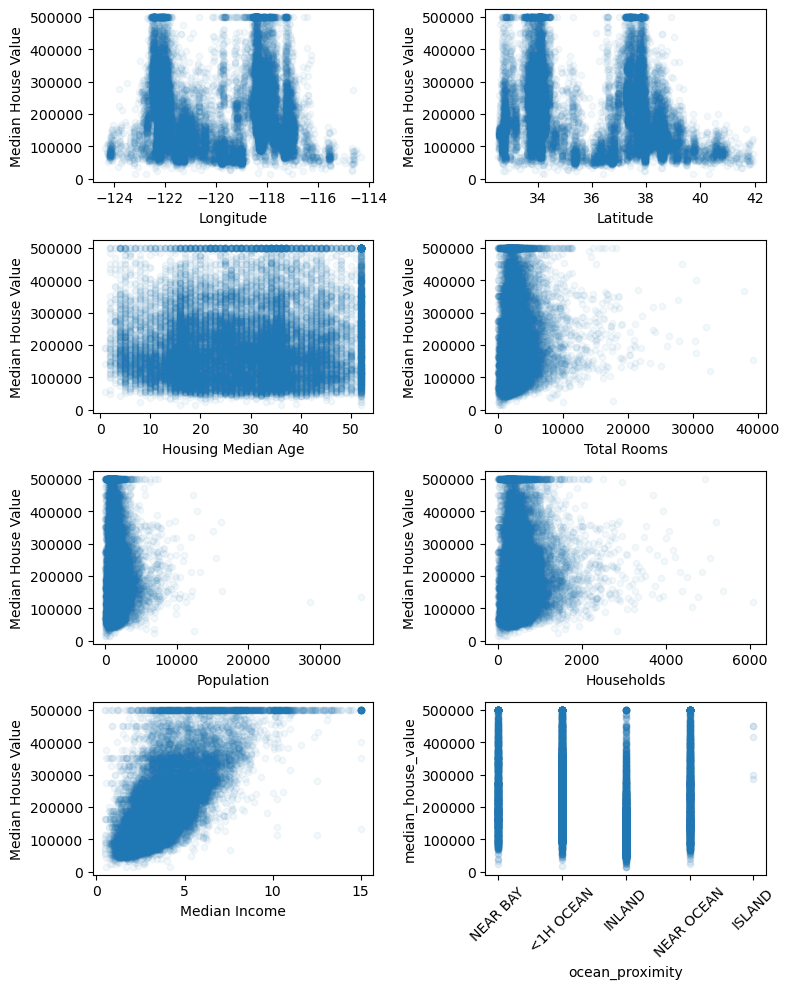

In [88]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8, 10))


filtered_df.plot(kind='scatter', x='longitude', y='median_house_value', ax=axes[0,0], alpha=0.05)
axes[0,0].set_xlabel('Longitude')
axes[0,0].set_ylabel('Median House Value')


filtered_df.plot(kind='scatter', x='latitude', y='median_house_value', ax=axes[0,1], alpha=0.05)
axes[0,1].set_xlabel('Latitude')
axes[0,1].set_ylabel('Median House Value')


filtered_df.plot(kind='scatter', x='housing_median_age', y='median_house_value', ax=axes[1,0], alpha=0.05)
axes[1,0].set_xlabel('Housing Median Age')
axes[1,0].set_ylabel('Median House Value')


filtered_df.plot(kind='scatter', x='total_rooms', y='median_house_value', ax=axes[1,1], alpha=0.05)
axes[1,1].set_xlabel('Total Rooms')
axes[1,1].set_ylabel('Median House Value')


filtered_df.plot(kind='scatter', x='population', y='median_house_value', ax=axes[2,0], alpha=0.05)
axes[2,0].set_xlabel('Population')
axes[2,0].set_ylabel('Median House Value')


filtered_df.plot(kind='scatter', x='households', y='median_house_value', ax=axes[2,1], alpha=0.05)
axes[2,1].set_xlabel('Households')
axes[2,1].set_ylabel('Median House Value')


filtered_df.plot(kind='scatter', x='median_income', y='median_house_value', ax=axes[3,0], alpha=0.05)
axes[3,0].set_xlabel('Median Income')
axes[3,0].set_ylabel('Median House Value')


# filtered_df.plot(kind='scatter', x='ocean_proximity', y='median_house_value', ax=axes[3,1], alpha=0.05)
# axes[3,1].set_xlabel('Ocean Proximity')
# axes[3,1].set_ylabel('Median House Value')

filtered_df.plot(kind='scatter', x='ocean_proximity', y='median_house_value', ax=axes[3,1], alpha=0.1)
axes[3,1].tick_params(axis='x', labelrotation=45)

	 	 	
plt.tight_layout()
plt.savefig("../figures/median_house_value_vs_variables.pdf")
plt.show()

## <font color='orange'> Corrrelation of Variables </font>

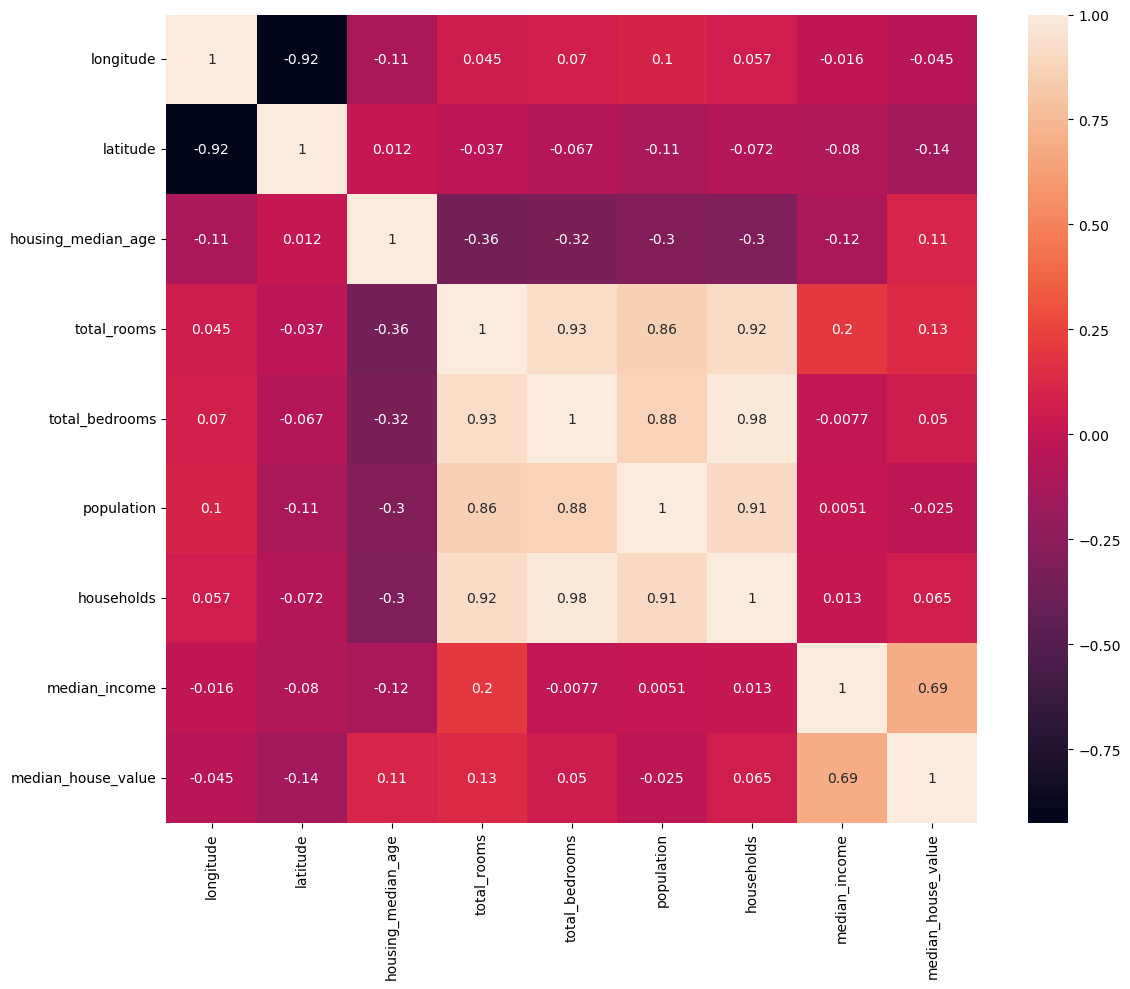

In [89]:
import seaborn as sns

corr_df = filtered_df.drop('ocean_proximity',  axis='columns')
corr = corr_df.corr(method='pearson')

plt.figure(figsize=(12, 10))

ax = sns.heatmap(corr, annot=True)
plt.tight_layout()
plt.savefig("../figures/variable_correlations.pdf")
plt.show()